# How generated blocks are bridged and stitched

The model makes rainfall **64 steps (5h20) at a time**. A 10-year series is thousands of these
blocks joined together. This notebook follows five blocks through the real generation code
(`regime_training/generate_hmm_v1.py`, the script behind v10) to show **when** bridging and
stitching happen and what each one does.

**Short answer**

| Step | When | What it works on | Code |
| :--- | :--- | :--- | :--- |
| 1. Choose a state for each block | before generation | labels only | Markov chain or calendar profile |
| 2. **Bridging** | **before generation** | labels only: adds an extra block with a blended label wherever the state changes | `build_generation_plan` (line 137) |
| 3. Generation | — | each block is made **on its own** from fresh noise; blocks never see each other | `batch_generate_blocks` (line 286) |
| 4. Back to mm | after generation | each finished block goes through the inverse transform | `main()` (line 603) |
| 5. **Stitching** | **after generation** | the mm blocks, overlapped and crossfaded; then anything below 0.005 mm becomes 0 | `stitch_blocks_transition_aware` (line 188), `main()` (lines 605–613) |

Until 2026-09-27 steps 4 and 5 ran the other way round (stitch in model space, then convert).
The last section shows why that was changed.

Every claim is checked below by running those functions on the v10 checkpoint. A counter on
the denoising network shows which steps actually run the model. Runs on CPU in under a minute.

In [1]:
import os, sys, pickle, argparse
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import regime_training.generate_hmm_v1 as gen      # the real generation script: we call its functions, not copies
from models.ImagenFew.ImagenFew import ImagenFew
from regime_training.transforms import make_scaler

# Same settings as the v10 generation job (scripts/run_v10_generation.sh)
RUN_DIR = '../logs/ImagenFew/Rainfall_Regime/aebe363f'     # v10
CONFIG = '../regime_training/config_v10.yaml'
OVERLAP, TRANSITION_OVERLAP, BRIDGE_BLOCKS = 4, 8, 1
WET_THR = 0.005

# Colours: validated categorical order (dataviz validator, light mode). Text stays in ink colours.
C = {'state 1': '#2a78d6', 'bridge': '#eb6834', 'state 3': '#1baf7a'}
INK, MUTED, GRID, BLEND = '#0b0b0b', '#52514e', '#e4e3df', '#f1f0ec'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
                     'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': GRID, 'grid.linewidth': 0.6, 'font.size': 10})

In [2]:
args = argparse.Namespace(**OmegaConf.to_container(OmegaConf.load(CONFIG), resolve=True))
args.device = 'cpu'

with open(f'{RUN_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load weights the same way gen.main() does: shape-matched weights, then the EMA weights
model = ImagenFew(args, args.device)
ckpt = torch.load(f'{RUN_DIR}/best_regime_model.pt', map_location='cpu', weights_only=False)
state = ckpt.get('model', ckpt)
cur = model.state_dict()
model.load_state_dict({k: v for k, v in state.items() if k in cur and v.shape == cur[k].shape}, strict=False)
cur_ema = model.model_ema.state_dict()
model.model_ema.load_state_dict({k: v for k, v in ckpt['ema_model'].items()
                                 if k in cur_ema and v.shape == cur_ema[k].shape}, strict=False)
model.eval()
process = gen.DiffusionProcess(args, model.net, (1, args.img_resolution, args.img_resolution))

# Count every call to the denoising network, so each step can show whether the model ran
net_calls = {'n': 0}
model.net.register_forward_hook(lambda *_: net_calls.__setitem__('n', net_calls['n'] + 1))

def calls_during(fn):
    # Run fn() and return (its result, how many times it called the network)
    before = net_calls['n']
    out = fn()
    return out, net_calls['n'] - before

def inv_mm(z):
    # Model space -> mm per 5 min (inverse transform only)
    return scaler.inverse_transform(np.asarray(z, dtype=np.float64).reshape(-1, 1)).ravel()

def to_mm(z):
    # ... then the same 0.005 mm threshold generation applies
    mm = inv_mm(z)
    mm[mm < WET_THR] = 0.0
    return mm

def overlaps_for(plan):
    # Overlap at each boundary, using the rule inside stitch_blocks_transition_aware:
    # wide overlap if the state changes or either side is a bridge, otherwise the base overlap
    return [TRANSITION_OVERLAP if (a['state'] != b['state'] or 'bridge' in (a['type'], b['type']))
            else OVERLAP for a, b in zip(plan[:-1], plan[1:])]

print(f'v10 loaded: n_classes={args.n_classes}, seq_len={args.seq_len}, scaler={scaler!r}')

v10 loaded: n_classes=4, seq_len=64, scaler=StandardScaler()


## Steps 1–2: choosing states, and bridging (before generation)

Take four blocks: two in HMM state 1 (light rain), then two in state 3 (heavy rain). That gives
one boundary where the state stays the same and one where it changes.

`build_generation_plan` turns the states into the list of labels the model will be given. At the
state change it **inserts a bridge block**: a whole extra 64-step block whose label is half
state 1 and half state 3.

In [3]:
states = np.array([1, 1, 3, 3])
plan, n_plan = calls_during(lambda: gen.build_generation_plan(states, n_bridge=BRIDGE_BLOCKS))

names = ['block 1', 'block 2', 'bridge', 'block 3', 'block 4']
kind = ['state 1', 'state 1', 'bridge', 'state 3', 'state 3']
captions = ['state 1', 'state 1', '½ state 1 + ½ state 3', 'state 3', 'state 3']
assert len(plan) == len(names)

print(f'network calls while building the plan (this is where bridging happens): {n_plan}')
pd.DataFrame({'block': names,
              'type': [p['type'] for p in plan],
              'state': [p['state'] if p['state'] is not None else '–' for p in plan],
              'label the model will get': [np.round(p['label_weights'], 2).tolist() for p in plan]})

network calls while building the plan (this is where bridging happens): 0


,block,type,state,label the model will get
0,block 1,normal,1,"[0.0, 1.0, 0.0, 0.0]"
1,block 2,normal,1,"[0.0, 1.0, 0.0, 0.0]"
2,bridge,bridge,–,"[0.0, 0.5, 0.0, 0.5]"
3,block 3,normal,3,"[0.0, 0.0, 0.0, 1.0]"
4,block 4,normal,3,"[0.0, 0.0, 0.0, 1.0]"


**Bridging is finished before the model runs once** (0 network calls). All it does is add a row
to a list of labels. It does not smooth or edit any rain. The bridge becomes a real block of
generated rain in the output.

Note: training only ever showed the model pure labels such as `[0, 1, 0, 0]`. The blended label
`[0, 0.5, 0, 0.5]` is new to it.

## Step 3: generation (each block on its own)

The sampler is an in-filling sampler. It gets a mask saying which pixels are already known (1)
and which to generate (0). `batch_generate_blocks` builds that mask like this:

In [4]:
mask = model.ts_to_img(torch.zeros(1, args.seq_len, 1), pad_val=1)
print(f'mask shape {tuple(mask.shape)}: known pixels = {int(mask.sum())} of {mask.numel()}')

mask shape (1, 1, 8, 8): known pixels = 0 of 64


**No pixel is known**, so no neighbour's values are passed in. Each block starts from its own
random noise and sees only its own label. Now generate all five blocks in one batch, as the
script does:

In [5]:
labels = [p['label_weights'] for p in plan]
torch.manual_seed(2)      # seed chosen so several blocks contain rain; most 5-hour blocks are fully dry
with model.ema_scope():
    blocks, n_gen = calls_during(lambda: gen.batch_generate_blocks(model, process, labels, args))
blocks_z = [b.squeeze(-1) for b in blocks]          # model space, 64 values per block

print(f'network calls during generation: {n_gen}')
for name, b in zip(names, blocks_z):
    mm = to_mm(b)
    print(f'  {name:8s} rain {mm.sum():5.2f} mm   wet steps {(mm > 0).sum():2d} / 64')

network calls during generation: 71
  block 1  rain  0.00 mm   wet steps  0 / 64
  block 2  rain  0.67 mm   wet steps 11 / 64
  bridge   rain  1.26 mm   wet steps 22 / 64
  block 3  rain  0.00 mm   wet steps  0 / 64
  block 4  rain  1.25 mm   wet steps 10 / 64


**Test that the blocks really are independent.** Change only block 2's label (state 1 → state 3)
and reuse the same random seed. If blocks were built from their neighbours, the blocks around
it would change too.

In [6]:
labels_changed = list(labels)
labels_changed[1] = np.eye(4, dtype=np.float32)[3]
torch.manual_seed(2)
with model.ema_scope():
    blocks_changed = gen.batch_generate_blocks(model, process, labels_changed, args)

for name, a, b in zip(names, blocks, blocks_changed):
    print(f'  {name:8s} largest change (model space): {np.abs(a - b).max():.1e}   '
          f'rain {to_mm(a).sum():.2f} -> {to_mm(b).sum():.2f} mm')

  block 1  largest change (model space): 0.0e+00   rain 0.00 -> 0.00 mm
  block 2  largest change (model space): 2.5e+00   rain 0.67 -> 1.07 mm
  bridge   largest change (model space): 0.0e+00   rain 1.26 -> 1.26 mm
  block 3  largest change (model space): 0.0e+00   rain 0.00 -> 0.00 mm
  block 4  largest change (model space): 0.0e+00   rain 1.25 -> 1.25 mm


Only block 2 changes; the blocks on both sides are exactly the same.
**The blocks never influence each other during generation.** So before
stitching, neighbouring blocks don't line up: rain can stop or start sharply at each edge.

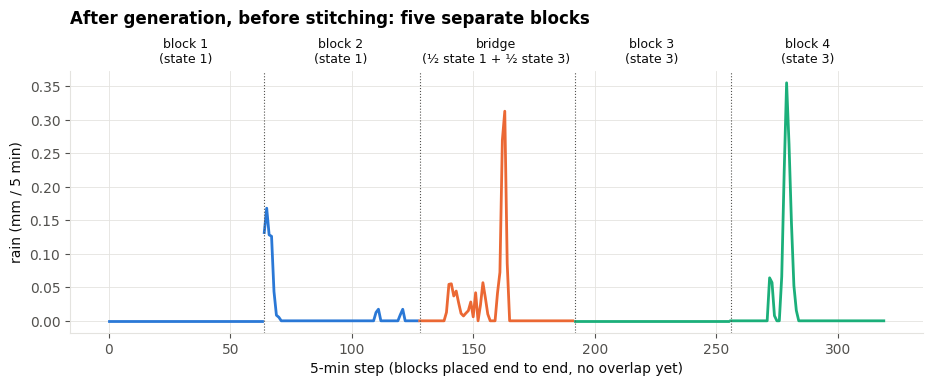

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for i, (name, k, cap, b) in enumerate(zip(names, kind, captions, blocks_z)):
    t = np.arange(args.seq_len) + args.seq_len * i
    ax.plot(t, to_mm(b), color=C[k], lw=2)
    if i:
        ax.axvline(args.seq_len * i, color=MUTED, lw=0.8, ls=':')
    ax.text(t.mean(), 1.02, f'{name}\n({cap})', transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=9, color=INK)
ax.set_xlabel('5-min step (blocks placed end to end, no overlap yet)')
ax.set_ylabel('rain (mm / 5 min)')
ax.set_title('After generation, before stitching: five separate blocks', loc='left',
             fontweight='bold', pad=34)
plt.show()

## Steps 4–5: back to mm, then stitching (after generation)

First `main()` converts each finished block to mm. Then `stitch_blocks_transition_aware`
overlaps neighbouring blocks and crossfades them:

* **4 steps** of overlap where the state stays the same (`--overlap 4`),
* **8 steps** wherever the state changes or a bridge is involved (`--transition_overlap 8`),
* inside an overlap, one block fades out while the next fades in (cosine ramps that add up to 1),
  so each step there is a **weighted average of two unrelated blocks**.

The crossfade averages rain **in mm**. The 0.005 mm threshold comes last.

In [8]:
blocks_mm = [inv_mm(b) for b in blocks_z]           # step 4: each block back to mm (main(), line 603)
stitched_mm, n_stitch = calls_during(lambda: gen.stitch_blocks_transition_aware(
    blocks_mm, plan, base_overlap=OVERLAP, transition_overlap=TRANSITION_OVERLAP))
final_mm = stitched_mm.copy()
final_mm[final_mm < WET_THR] = 0.0                  # threshold last (main(), line 613)

print(f'network calls during stitching: {n_stitch}')
print(f'length: {len(blocks_mm)} blocks x {args.seq_len} = {len(blocks_mm) * args.seq_len} steps '
      f'-> {len(stitched_mm)} after overlapping')

network calls during stitching: 0
length: 5 blocks x 64 = 320 steps -> 296 after overlapping


In [9]:
# Rebuild each block's position and crossfade weight from the stitching rule, and check the
# rebuild matches the real function exactly (so the figure below shows what the script did).
L = args.seq_len
ovs = overlaps_for(plan)
starts = np.concatenate([[0], np.cumsum([L - o for o in ovs])]).astype(int)

def ramp(n, up):
    m = np.arange(n) + 0.5
    return 0.5 * (1 - np.cos(np.pi * m / n)) if up else 0.5 * (1 + np.cos(np.pi * m / n))

weights = []
for i in range(len(plan)):
    w = np.ones(L)
    if i > 0:
        w[:ovs[i - 1]] = ramp(ovs[i - 1], up=True)
    if i < len(plan) - 1:
        w[-ovs[i]:] = ramp(ovs[i], up=False)
    weights.append(w)

rebuilt, wsum = np.zeros(len(stitched_mm)), np.zeros(len(stitched_mm))
for s, w, b in zip(starts, weights, blocks_mm):
    rebuilt[s:s + L] += w * b
    wsum[s:s + L] += w
assert np.allclose(rebuilt / wsum, stitched_mm, atol=1e-5), 'rebuild does not match the script'

print('overlap at each boundary:', dict(zip([f'{a} | {b}' for a, b in zip(names[:-1], names[1:])], ovs)))
print('rebuild matches stitch_blocks_transition_aware; weights add up to 1 everywhere:',
      bool(np.allclose(wsum, 1)))

overlap at each boundary: {'block 1 | block 2': 4, 'block 2 | bridge': 8, 'bridge | block 3': 8, 'block 3 | block 4': 4}
rebuild matches stitch_blocks_transition_aware; weights add up to 1 everywhere: True


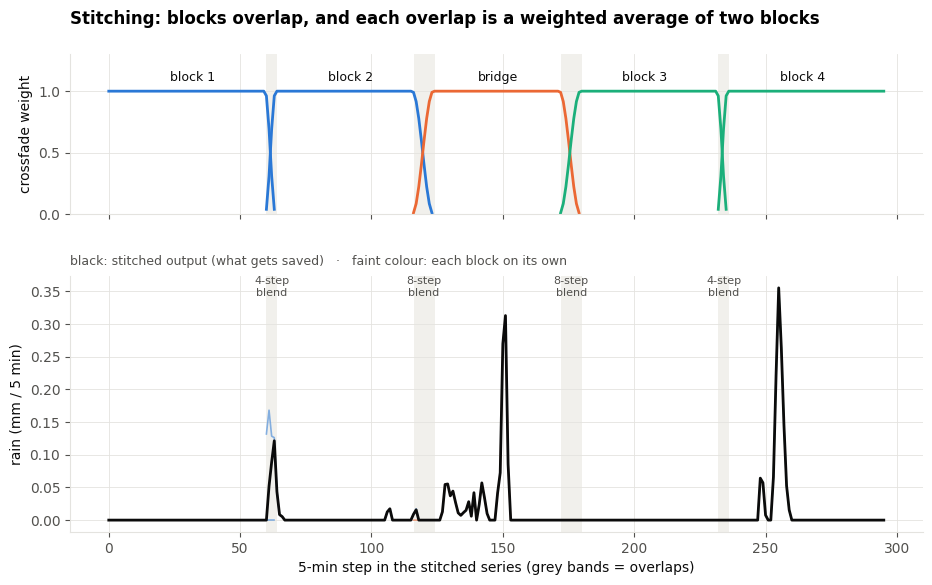

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1.6], 'hspace': 0.3})
for ax in (ax1, ax2):
    for s, o in zip(starts[1:], ovs):
        ax.axvspan(s, s + o, color=BLEND, lw=0, zorder=0)

for name, k, s, w, b in zip(names, kind, starts, weights, blocks_z):
    t = np.arange(L) + s
    ax1.plot(t, w, color=C[k], lw=2)
    ax1.text(s + L / 2, 1.06, f'{name}', ha='center', va='bottom', fontsize=9, color=INK)
    ax2.plot(t, to_mm(b), color=C[k], lw=1.2, alpha=0.55)
ax2.plot(np.arange(len(final_mm)), final_mm, color=INK, lw=2)
for s, o in zip(starts[1:], ovs):
    ax2.text(s + o / 2, 1.0, f'{o}-step\nblend', transform=ax2.get_xaxis_transform(),
             ha='center', va='top', fontsize=8, color=MUTED)

ax1.set_ylim(0, 1.3)
ax1.set_ylabel('crossfade weight')
ax1.set_title('Stitching: blocks overlap, and each overlap is a weighted average of two blocks',
              loc='left', fontweight='bold', pad=22)
ax2.set_ylabel('rain (mm / 5 min)')
ax2.set_xlabel('5-min step in the stitched series (grey bands = overlaps)')
ax2.set_title('black: stitched output (what gets saved)   ·   faint colour: each block on its own',
              loc='left', fontsize=9, color=MUTED, pad=8)
plt.show()

Outside the grey bands the output is exactly one block. Inside them it is a mix of two blocks
that were generated without knowing about each other. For example, at step ~60 the start of
block 2's shower is averaged with the dry end of block 1, so its first peak is softened.

In [11]:
pd.DataFrame({
    'step': ['1-2. plan + bridging', '3. generation', '4. back to mm', '5. stitching'],
    'when': ['BEFORE generation', 'generation', 'after generation', 'AFTER generation'],
    'network calls': [n_plan, n_gen, 0, n_stitch],
    'works on': ['labels only', 'noise -> one block each, independently',
                 'each finished block -> mm', 'mm blocks crossfaded, then < 0.005 mm -> 0'],
}).set_index('step')

,when,network calls,works on
step,,,
1-2. plan + bridging,BEFORE generation,0,labels only
3. generation,generation,71,"noise -> one block each, independently"
4. back to mm,after generation,0,each finished block -> mm
5. stitching,AFTER generation,0,"mm blocks crossfaded, then < 0.005 mm -> 0"


## What this means for a 10-year series

Three consequences, measured on the real 10-year **calendar** plan that v10_cal uses (built with
the same code as `gen.main()`; no model needed for this part).

In [12]:
with open('../data/rainfall/splits/seasonal_transition_matrix_train_len64.pkl', 'rb') as f:
    clim = pickle.load(f)['climatology_profile_1yr']

STEPS_PER_YEAR, YEARS = 365 * 288, 10
stride = L - OVERLAP
total = YEARS * STEPS_PER_YEAR
n_base = int(np.ceil(total / stride)) + 10                                          # as in gen.main()
cal_states = np.array([clim[(k * stride) % len(clim)] for k in range(n_base)], dtype=int)   # calendar mode
cal_plan = gen.build_generation_plan(cal_states, n_bridge=BRIDGE_BLOCKS)

cal_ovs = overlaps_for(cal_plan)
cal_starts = np.concatenate([[0], np.cumsum([L - o for o in cal_ovs])])
used = cal_starts < total

blended = sum(o for o, s in zip(cal_ovs, cal_starts[1:]) if s < total) / total
is_bridge = np.array([p['type'] == 'bridge' for p in cal_plan])
normal = np.flatnonzero(~is_bridge & used)
# The calendar picks the k-th normal block's state as if it starts at step k * stride.
# Bridge blocks and the wider 8-step overlaps move the real start, so the seasons drift.
drift_days = (cal_starts[normal] - np.arange(len(normal)) * stride) / 288
yr1 = np.searchsorted(np.arange(len(normal)) * stride, STEPS_PER_YEAR)

print(f'state changes in 10 years: {int(is_bridge.sum())}  (one bridge block each)')
print(f'steps that are a blend of two independent blocks: {blended:.1%}')
print(f'steps that come from bridge blocks (approx.):     {is_bridge[used].sum() * (L - 2 * TRANSITION_OVERLAP) / total:.1%}')
print(f'calendar drift: {drift_days[yr1]:.1f} days late after year 1, {drift_days[-1]:.1f} days late by year {YEARS}')

state changes in 10 years: 220  (one bridge block each)
steps that are a blend of two independent blocks: 6.8%
steps that come from bridge blocks (approx.):     1.0%
calendar drift: 4.0 days late after year 1, 39.2 days late by year 10


**1. Blocks only meet at the crossfade.** About 7% of all steps are an average of two blocks
that never saw each other. That is where storms can be cut in half or softened. Bridge blocks,
the only other link, make up about 1% of the series.

**2. The calendar slowly drifts (calendar mode only).** Each bridge adds time that the calendar
index doesn't count, so the seasons fall a few days further behind every year. This affects the
monthly seasonality score (Tier 5) of every `_cal` version.

**3. Why stitching now happens in mm.** Until 2026-09-27 the script stitched in model space.
With StandardScaler (v10), a weighted average in model space is the same weighted average in mm.
With log1p (v13) or asinh (v14) it is not: averaging in a squashed space gives less rain once
converted back. Below, real 2000–2007 rainfall is cut into 64-step blocks, shuffled so
neighbours are unrelated (like generated blocks), and stitched both ways:

In [13]:
x_train = pd.read_csv('../data/rainfall/splits/train_years_labelled.csv')['avg_rainfall'].values
n_blk = len(x_train) // L
real_blocks = x_train[:n_blk * L].reshape(n_blk, L)[np.random.default_rng(0).permutation(n_blk)]
flat_plan = [{'type': 'normal', 'state': 1}] * n_blk          # same state -> base overlap everywhere

def threshold(a):
    a = a.copy()
    a[a < WET_THR] = 0.0
    return a

rows = []
for name, version in [('standard', 'v10'), ('log1p', 'v13'), ('asinh', 'v14')]:
    sc = make_scaler(name, 0.035).fit(x_train.reshape(-1, 1))
    z01 = sc.transform(np.array([[0.0], [1.0]])).ravel()
    half = sc.inverse_transform([[z01.mean()]])[0, 0]
    in_model = threshold(sc.inverse_transform(gen.stitch_blocks_transition_aware(
        [sc.transform(b.reshape(-1, 1)).ravel() for b in real_blocks], flat_plan, OVERLAP, TRANSITION_OVERLAP
    ).reshape(-1, 1)).ravel())
    in_mm = threshold(gen.stitch_blocks_transition_aware(
        [b.astype(np.float32) for b in real_blocks], flat_plan, OVERLAP, TRANSITION_OVERLAP))
    rows.append({'transform': name, 'version': version,
                 '50/50 blend of 0 mm and 1 mm': f'{half:.2f} mm',
                 'rain volume, stitched in model space (old) vs in mm (now)': f'{in_model.sum() / in_mm.sum() - 1:+.2%}'})
pd.DataFrame(rows).set_index('transform')

,version,50/50 blend of 0 mm and 1 mm,"rain volume, stitched in model space (old) vs in mm (now)"
transform,,,
standard,v10,0.50 mm,+0.00%
log1p,v13,0.41 mm,-0.19%
asinh,v14,0.13 mm,-1.37%


The effect was small (about 1% less rain for asinh) but systematic, and it came from stitching,
not from the model. That is why each block is now converted to mm **before** stitching. For v10
this changes nothing, because a linear map commutes with averaging: old and new code on the v10
checkpoint (0.1 years, calendar and Markov) gave the same output to within 1e-7 mm.

## Summary

* **Bridging happens before generation.** It only edits the list of labels, adding one
  blended-label block at each state change. 0 model calls.
* **Generation makes every block on its own.** Nothing is passed between blocks.
* **Stitching happens after generation.** Finished blocks are converted to mm, then crossfaded
  over 4 or 8 steps. 0 model calls.
* For the v10 / v13 / v14 comparison, bridging and calendar drift are identical across the three
  runs, and because stitching now happens in mm it treats all three transforms the same.